In [1]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
import matplotlib.pyplot as plt 
import torch.optim as optim
import torch.nn as nn 
import torch
import seaborn as sns
import numpy as np
import pandas as pd 
import re

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [3]:
def clean_values(value):
    if pd.isna(value): return np.nan
    cleaned_str = re.sub(r'[^\d\.\-]', '', str(value)) #delete non numeric characters

    try:
        if '-' in cleaned_str: #use the mean of the interval for values containing -
            parts = cleaned_str.split('-')
            nums = [float(p) for p in parts if p]
            return sum(nums)/len(nums) if nums else np.nan
        else:
            return float(cleaned_str)
    except ValueError:
        return np.nan

In [4]:
# keep CC , Returns NaN for Electric (kWh)
def extract_engine_volume(value):
    if pd.isna(value): return np.nan
    val_str = str(value).lower().replace(',', '')
    
    if 'cc' in val_str:
        number = re.search(r'(\d+\.?\d*)', val_str)
        if number:
            return float(number.group(1))

    return np.nan

In [5]:
def simplify_engine(engine_str):
    if pd.isna(engine_str): return 'Unknown'
    engine_str = str(engine_str).upper()
    
    if 'ELECTRIC' in engine_str: return 'Electric'
    if 'V8' in engine_str or 'V12' in engine_str or 'V10' in engine_str or 'V6' in engine_str: return 'V-Engine'
    if 'I4' in engine_str or 'INLINE-4' in engine_str or 'I3' in engine_str: return 'Inline-Engine'
    if 'HYBRID' in engine_str: return 'Hybrid'
    return 'Other'


In [6]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        X = np.array(X, dtype=np.float64) 
        self.mean = np.nanmean(X, axis=0)
        self.std = np.nanstd(X, axis=0)
        
        if np.isscalar(self.std):
            if self.std == 0:
                self.std = 1.0
        else:
            self.std = np.where(self.std == 0, 1.0, self.std)
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64) 
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [7]:
def train_test_split(df, train_ratio=0.7, val_ratio=0.15, random_state=42):
    np.random.seed(random_state)
    n_samples =len(df)

    indices = np.random.permutation(n_samples)

    split_idx1 = int(train_ratio * n_samples)
    split_idx2 = int((train_ratio+val_ratio) * n_samples)

    train_idx = indices[:split_idx1]
    val_idx = indices[split_idx1:split_idx2]
    test_idx = indices[split_idx2:]

    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]

In [8]:
class Preprocessing:
    def __init__(self, numeric_features, categorical_features):
        self.num_cols = numeric_features
        self.cat_cols = categorical_features
        self.impute_vals = {} #to save train means to avoid data leakage
        self.scaler = standardScaler()
        self.ohe_cols = None

    def fit(self, X_train):
        for col in self.num_cols:
            self.impute_vals[col] = X_train[col].mean()
        # fill numeric null values with mean
        X_train = X_train[self.num_cols].fillna(self.impute_vals)
        self.scaler.fit(X_train)
        return self
    

    def transform(self, df):
        df = df.copy()
        # fill numeric null values with train mean:
        for col in self.num_cols:
            df[col] = df[col].fillna(self.impute_vals.get(col, 0))

        # fill categorical null values with Unknown
        for col in self.cat_cols:
            df[col] = df[col].fillna('Unknown')

        df[self.num_cols] = self.scaler.transform(df[self.num_cols])

        return df

In [9]:
def one_hot_encoder(X_train, X_val, X_test,categorical_cols):
    #one hot encoding, creating cols like Fuel-Petrol and Fuel-Diesel
    X_train_ohe = pd.get_dummies(X_train, columns=categorical_cols, dummy_na=False)
    X_val_ohe = pd.get_dummies(X_val, columns=categorical_cols, dummy_na=False)
    X_test_ohe = pd.get_dummies(X_test, columns=categorical_cols, dummy_na=False)

    #if a value exists in train but not in val, fill it with 0, but if it was not in train, delete it. 
    X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)
    X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)
    print("One-Hot Encoding Finished. Shape:", X_train_ohe.shape)

    return X_train_ohe, X_val_ohe, X_test_ohe

In [10]:
df = pd.read_csv('Cars Datasets.csv')

In [11]:
df['CC/Battery Capacity'] = df['CC/Battery Capacity'].apply(extract_engine_volume)
df['Engines'] = df['Engines'].apply(simplify_engine)

cols_to_clean = ['Cars Prices', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Torque']

for col in cols_to_clean:
    df[col] = df[col].apply(clean_values)

df['Cars Prices'] = np.log1p(df['Cars Prices'])
df = df.dropna(subset=['Cars Prices']).reset_index(drop=True)

#delete car name
selected_features = ['Company Names', 'Engines','CC/Battery Capacity', 'HorsePower', 'Torque', 'Fuel Types', 'Performance(0 - 100 )KM/H', 'Total Speed', 'Seats', 'Cars Prices']

numeric_cols = ['Cars Prices', 'CC/Battery Capacity','Performance(0 - 100 )KM/H', 'HorsePower', 'Torque', 'Total Speed', 'Seats']

categorical_cols = ['Company Names', 'Engines', 'Fuel Types']

data = df[selected_features].copy()

train_df, val_df, test_df = train_test_split(data, train_ratio=0.7, val_ratio=0.15, random_state=42)

preprocessor = Preprocessing(numeric_cols, categorical_cols)
preprocessor.fit(train_df)

train_df = preprocessor.transform(train_df)
val_df = preprocessor.transform(val_df)
test_df = preprocessor.transform(test_df)

X_train, X_val, X_test = one_hot_encoder(train_df, val_df, test_df, categorical_cols)


One-Hot Encoding Finished. Shape: (851, 67)


In [12]:
def get_euclidean_matrix(X):
    X = np.array(X)
    sum_sq = np.sum(X**2, axis=1, keepdims=True)
    dist_sq = sum_sq + sum_sq.T - 2 * np.dot(X, X.T)
    dist_sq = np.maximum(dist_sq, 0)
    return np.sqrt(dist_sq)

def get_k_dist_plot(X, k_values=[3, 5, 8, 10]):
    dist_matrix = get_euclidean_matrix(X)
    print(f"Distance Matrix Shape: {dist_matrix.shape}")
    plt.figure(figsize=(10, 6))

    for k in k_values:
        sorted_dists = np.sort(dist_matrix, axis=1)
        if k < sorted_dists.shape[1]:
            k_dists = sorted_dists[:, k]
            k_dists = np.sort(k_dists)
            plt.plot(k_dists, label=f'MinPts (k) = {k}')
        else:
            print(f"Warning: k={k} is larger than number of samples!")
    plt.title('K-Distance Graph for Eps Estimation')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'Distance to k-th nearest neighbor')
    plt.ylim(0, 7)
    plt.grid(True)
    plt.legend()
    plt.show()

In [13]:
def get_silhouette_score(X, labels):
    mask = labels!= -1
    X_clean = X[mask]
    labels_clean = labels[mask]

    n_samples = len(X_clean)
    unique_labels = np.unique(labels_clean)

    if len(unique_labels) < 2:
        return 0.0
    
    dist_matrix = get_euclidean_matrix(X_clean)

    s_scores = []

    for i in range(n_samples):
        current_label = labels_clean[i]

        same_cluster_mask = (labels_clean == current_label)
        same_cluster_mask[i] = False #we do not want to calculate the point i it self in the mean

        if np.sum(same_cluster_mask) > 0:
            a_i = np.mean(dist_matrix[i, same_cluster_mask])
        else: #if the cluster has only 1 point
            a_i = 0

        other_cluster_distances = []
        for other_label in unique_labels:
            if other_label == current_label:
                continue

            other_cluster_mask = (labels_clean == other_label)
            avg_dist_to_other_cluster = np.mean(dist_matrix[i, other_cluster_mask])
            other_cluster_distances.append(avg_dist_to_other_cluster)

        b_i = min(other_cluster_distances)
        
        if max(a_i, b_i) == 0:
            s_i = 0
        else:
            s_i = (b_i - a_i) / max(a_i, b_i)
        
        s_scores.append(s_i)
    
    return np.mean(s_scores)

In [ ]:
class DBSCAN:
    def __init__(self, eps, min_pts):
        self.eps = eps
        self.min_pts = min_pts
        self.labels_ = None

    def fit(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        self.labels_ = np.full(n_samples, -2)

        dist_matrix = get_euclidean_matrix(X)

        cluster_id = -1

        for i in range(n_samples):
            if self.labels_[i]  != -2:
                continue

            neighbors = np.where(dist_matrix[i] <= self.eps)[0]

            if len(neighbors) < self.min_pts:
                self.labels_[i] = -1 #it is noise
            else:
                cluster_id += 1
                self.expand_cluster(i, neighbors, cluster_id, dist_matrix)

        return self
    

    def expand_cluster(self, center_idx, neighbors, cluster_id, dist_matrix):
        self.labels_[center_idx] = cluster_id
        seeds = list(neighbors)
        i=0
        while i < len(seeds):
            neighbor_idx = seeds[i]

            if self.labels_[neighbor_idx] == -1: #if it was noise, it becomes مرزی :)
                self.labels_[neighbor_idx] = cluster_id


            elif self.labels_[neighbor_idx] == -2: #if it has not been seen yet, we add it to thr cluster and and join the seed to check its neighbors
                self.labels_[neighbor_idx] = cluster_id
                new_neighbors = np.where(dist_matrix[neighbor_idx] <= self.eps)[0]

                if len(new_neighbors) >= self.min_pts:
                   for n_idx in new_neighbors:
                        if n_idx not in seeds:
                            seeds.append(n_idx)
            i += 1

Plotting K-Distance Graph for Comb_1...
Distance Matrix Shape: (851, 851)


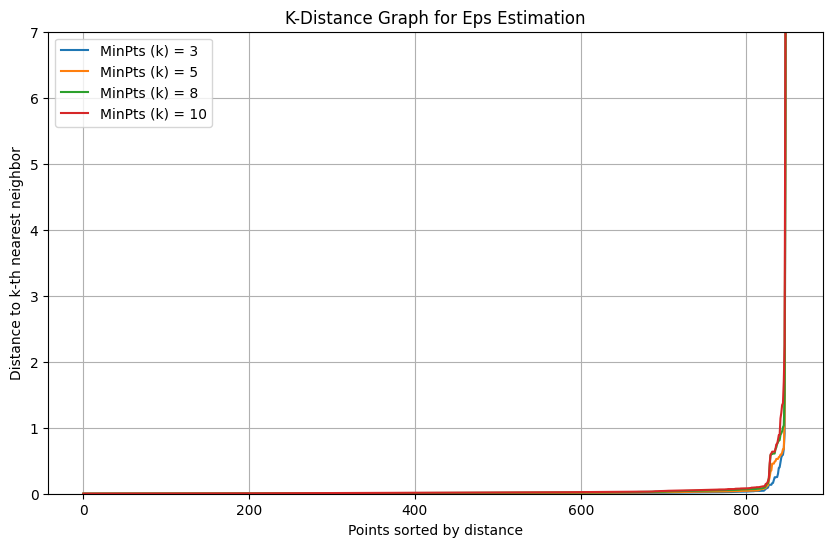

Plotting K-Distance Graph for Comb_2...
Distance Matrix Shape: (851, 851)


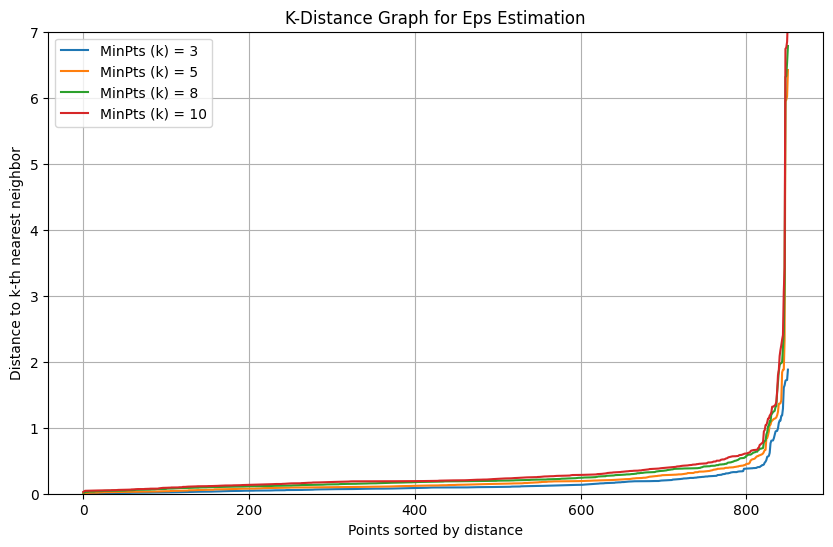

Plotting K-Distance Graph for Comb_3...
Distance Matrix Shape: (851, 851)


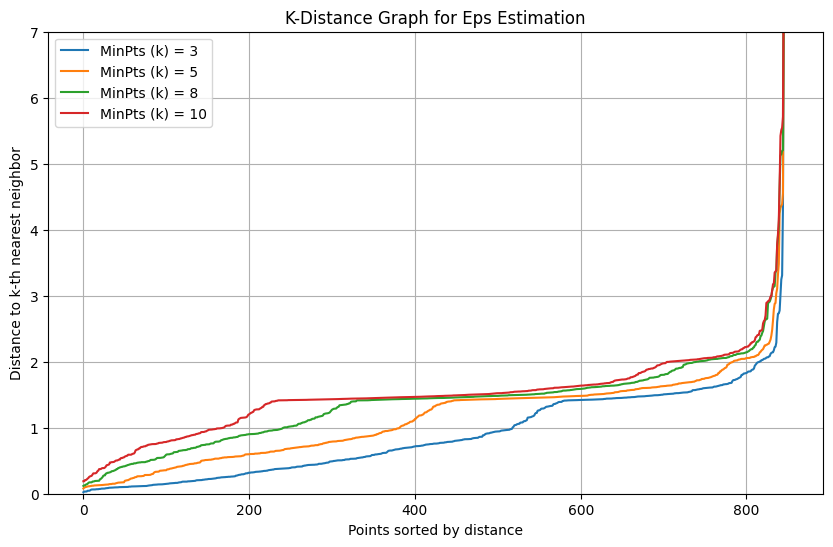

In [15]:
engine_cols = [col for col in X_train.columns if col.startswith('Engines_')]

combinations = {
    "Comb_1": ['Cars Prices', 'HorsePower'],
    "Comb_2": ['Cars Prices', 'Total Speed'] + engine_cols,
    "Comb_3": X_train.columns.tolist()
}

for name, features in combinations.items():
    X_subset = X_train[features].astype(float).values
    print(f"Plotting K-Distance Graph for {name}...")
    get_k_dist_plot(X_subset, k_values=[3, 5, 8, 10])

In [ ]:
class OPTICS:
    def __init__(self, min_pts, eps=np.inf):
        self.min_pts = min_pts
        self.eps = eps
        self.reachability_ = None
        self.ordering_ = None
        self.core_dists_ = None
        self.labels_ = None

    def fit(self, X):
        X = np.array(X)
        n = X.shape[0]
        dist_matrix = get_euclidean_matrix(X)

        self.reachability_ = np.full(n, np.inf)
        self.core_dists_ = np.full(n, np.inf)
        processed = np.full(n, False)
        self.ordering_ = []

        for i in range(n):
            sorted_dists = np.sort(dist_matrix[i])
            if len(sorted_dists) >= self.min_pts:
                self.core_dists_[i] = sorted_dists[self.min_pts - 1]

        for i in range(n):
            if not processed[i]:
                self.expand_cluster_order(i, dist_matrix, processed)

        self.labels_ = self.extract_labels()
        return self.labels_
    

    def extract_labels(self):
        n = len(self.ordering_)
        labels = np.full(n, -1)
        cluster_id = -1
        
        for i in self.ordering_:
            if self.reachability_[i] > self.eps:
                if self.core_dists_[i] <= self.eps:
                    cluster_id += 1
                    labels[i] = cluster_id
                else:
                    labels[i] = -1
            else:
                labels[i] = cluster_id
        return labels


    def expand_cluster_order(self, point_idx, dist_matrix, processed):
        seeds = [point_idx]
        processed[point_idx] = True
        self.ordering_.append(point_idx)
        
        if self.core_dists_[point_idx] > self.eps:  #stop if it is not a core
            return

        while seeds:
            seeds.sort(key=lambda x: self.reachability_[x])
            curr_idx = seeds.pop(0)
            
            neighbors = np.where(dist_matrix[curr_idx] <= self.eps)[0]
            
            if self.core_dists_[curr_idx] <= self.eps:
                for neighbor_idx in neighbors:
                    if not processed[neighbor_idx]:
                        new_reach_dist = max(self.core_dists_[curr_idx], dist_matrix[curr_idx, neighbor_idx])
                        
                        if self.reachability_[neighbor_idx] == np.inf:
                            self.reachability_[neighbor_idx] = new_reach_dist
                            seeds.append(neighbor_idx)
                            processed[neighbor_idx] = True
                            self.ordering_.append(neighbor_idx)
                        else:
                            if new_reach_dist < self.reachability_[neighbor_idx]:
                                self.reachability_[neighbor_idx] = new_reach_dist

Features: 2 | Eps: 0.125 | MinPts: 3
DBSCAN Silhouette: 0.6597

[DBSCAN Results for Comb_1]
Number of clusters: 3
Number of noise points: 16


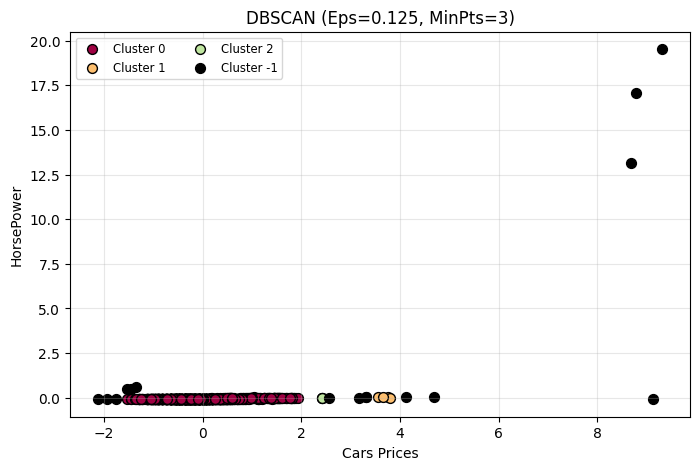


[OPTICS Results for Comb_1]
Running OPTICS...
Number of clusters in OPTICS: 3
Number of noise points in OPTICS: 17
OPTICS Silhouette: 0.6595


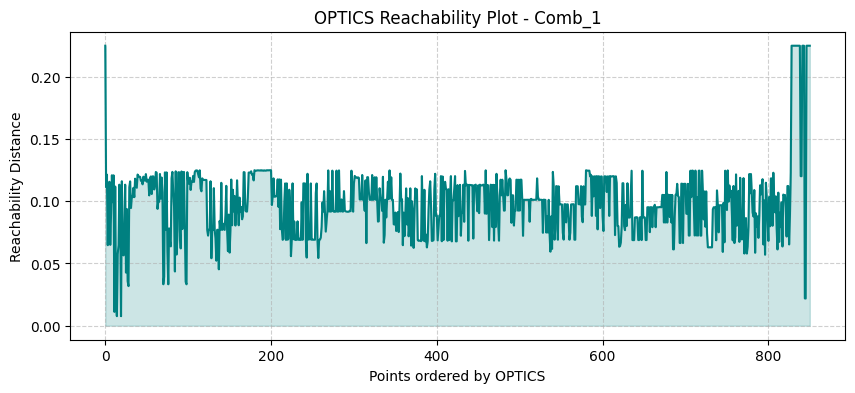

Features: 7 | Eps: 0.4 | MinPts: 3
DBSCAN Silhouette: 0.2877

[DBSCAN Results for Comb_2]
Number of clusters: 8
Number of noise points: 29


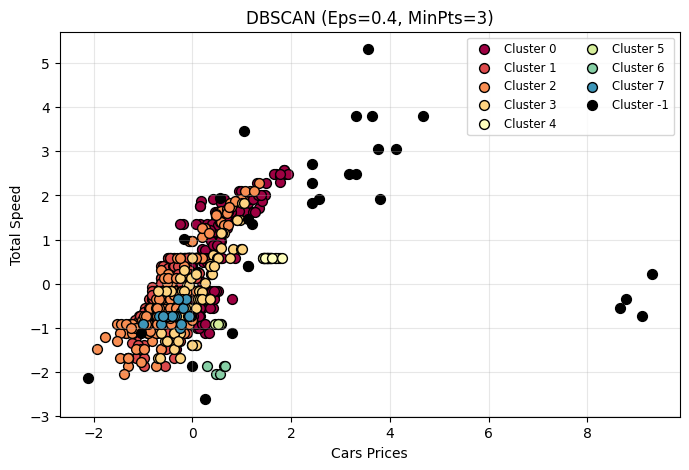


[OPTICS Results for Comb_2]
Running OPTICS...
Number of clusters in OPTICS: 8
Number of noise points in OPTICS: 29
OPTICS Silhouette: 0.2877


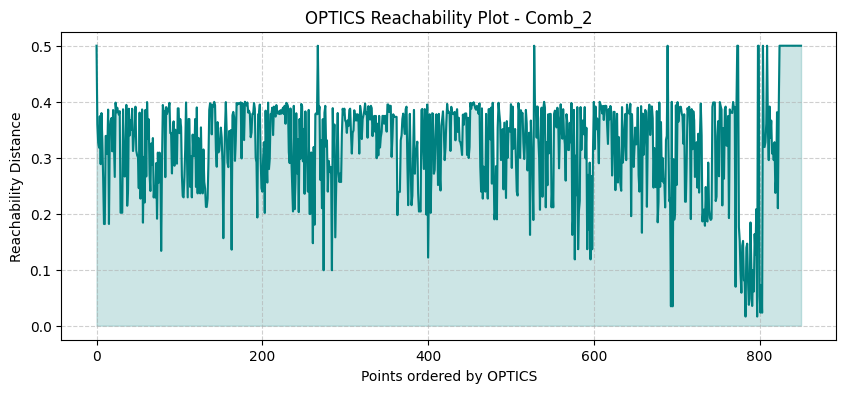

Features: 67 | Eps: 1.75 | MinPts: 3
DBSCAN Silhouette: -0.0058

[DBSCAN Results for Comb_3]
Number of clusters: 6
Number of noise points: 32


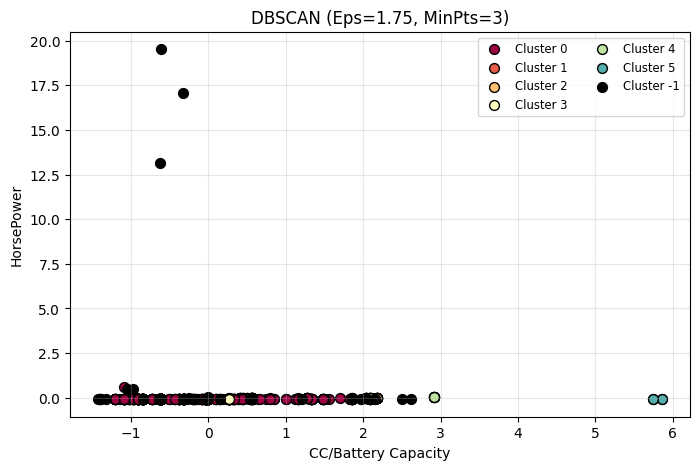


[OPTICS Results for Comb_3]
Running OPTICS...
Number of clusters in OPTICS: 6
Number of noise points in OPTICS: 32
OPTICS Silhouette: -0.0058


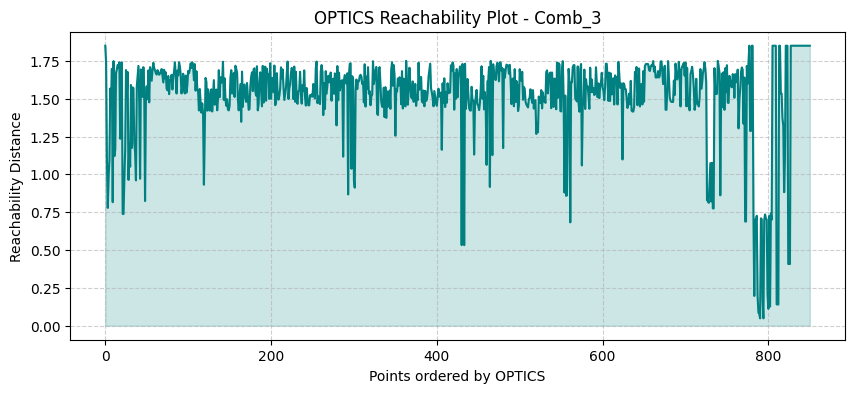

In [17]:
EPS = [0.125, 0.4, 1.75]
MIN_PTS = 3
best_score = -1
best_labels = None
best_combination_name = ""


for i, (name, features) in enumerate(combinations.items()):
    X_subset = X_train[features].astype(float).values
    current_eps = EPS[i]
    dbscan = DBSCAN(eps=current_eps, min_pts=MIN_PTS)
    dbscan.fit(X_subset)
    labels = dbscan.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"Features: {len(features)} | Eps: {current_eps} | MinPts: {MIN_PTS}")

    db_sil = get_silhouette_score(X_subset, labels)
    print(f"DBSCAN Silhouette: {db_sil:.4f}")


    if db_sil > best_score:
        best_score = db_sil
        best_labels = labels
        best_combination_name = name


    print(f"\n[DBSCAN Results for {name}]")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")

    plt.figure(figsize=(8, 5))
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1: col = [0, 0, 0, 1] # Black for noise
        class_member_mask = (labels == k)
        xy = X_subset[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], color=tuple(col), edgecolor='k', s=50, label=f'Cluster {k}')

    plt.title(f'DBSCAN (Eps={current_eps}, MinPts={MIN_PTS})')
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

    print(f"\n[OPTICS Results for {name}]")
    print("Running OPTICS...")
    optics = OPTICS(min_pts=MIN_PTS, eps=current_eps)
    optics.fit(X_subset)

    optics_labels = optics.fit(X_subset)
    n_clusters_optics = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
    n_noise_optics = list(optics_labels).count(-1)
    print(f"Number of clusters in OPTICS: {n_clusters_optics}")
    print(f"Number of noise points in OPTICS: {n_noise_optics}")
    
    op_sil = get_silhouette_score(X_subset, optics_labels)
    print(f"OPTICS Silhouette: {op_sil:.4f}")

    reachability = optics.reachability_[optics.ordering_]
    reachability[reachability == np.inf] = np.max(reachability[reachability != np.inf]) + 0.1

    plt.figure(figsize=(10, 4))
    plt.plot(reachability, color='teal', linewidth=1.5)
    plt.fill_between(range(len(reachability)), reachability, color='teal', alpha=0.2)
    plt.title(f'OPTICS Reachability Plot - {name}')
    plt.xlabel('Points ordered by OPTICS')
    plt.ylabel('Reachability Distance')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


In [18]:
class Hierarchical:
    def __init__(self, n_clusters=3, linkage='single'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None

    def fit(self, X):
        X = np.array(X)
        n_samples = X.shape[0]
        
        self.clusters = {i: [i] for i in range(n_samples)}
        
        cluster_sizes = {i: 1 for i in range(n_samples)}
        active_clusters_count = n_samples
        
        diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
        dist_matrix = np.sqrt(np.sum(diff**2, axis=-1))
        
        np.fill_diagonal(dist_matrix, np.inf)

        print(f"Starting {self.linkage} clustering on {n_samples} samples...")

        while active_clusters_count > self.n_clusters:
            
            min_idx = np.argmin(dist_matrix)
            c1, c2 = np.unravel_index(min_idx, dist_matrix.shape)
            
            if dist_matrix[c1, c2] == np.inf:
                break
            
            if c1 > c2: c1, c2 = c2, c1
            
            self.clusters[c1].extend(self.clusters[c2])
            
            d1_vec = dist_matrix[c1, :]
            d2_vec = dist_matrix[c2, :]
            
            if self.linkage == 'single':
                # min(d(c1,k), d(c2,k))
                new_dists = np.minimum(d1_vec, d2_vec)
                
            elif self.linkage == 'complete':
                # max(d(c1,k), d(c2,k))
                new_dists = np.maximum(d1_vec, d2_vec)
                
            elif self.linkage == 'average':
                n1 = cluster_sizes[c1]
                n2 = cluster_sizes[c2]
                # (n1*d1 + n2*d2) / (n1+n2)
                new_dists = (n1 * d1_vec + n2 * d2_vec) / (n1 + n2)
            
            dist_matrix[c1, :] = new_dists
            dist_matrix[:, c1] = new_dists
            dist_matrix[c1, c1] = np.inf
            
            dist_matrix[c2, :] = np.inf
            dist_matrix[:, c2] = np.inf
            
            cluster_sizes[c1] += cluster_sizes[c2]
            del self.clusters[c2] 
            del cluster_sizes[c2]
            
            active_clusters_count -= 1

        self.labels_ = np.full(n_samples, -1, dtype=int)
        
        final_mapping = {old_id: new_id for new_id, old_id in enumerate(self.clusters.keys())}
        
        for c_id, points in self.clusters.items():
            mapped_id = final_mapping[c_id]
            for p_idx in points:
                self.labels_[p_idx] = mapped_id
                
        return self.labels_

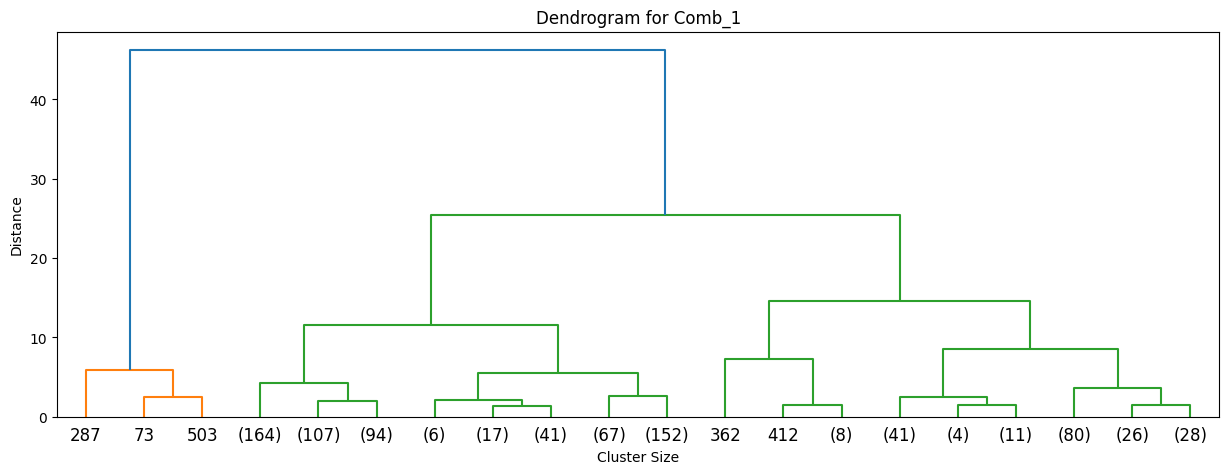

Processing Comb_1 with single linkage...
Starting single clustering on 851 samples...
Hierarchical Silhouette: 0.9057
Processing Comb_1 with complete linkage...
Starting complete clustering on 851 samples...
Hierarchical Silhouette: 0.7855
Processing Comb_1 with average linkage...
Starting average clustering on 851 samples...
Hierarchical Silhouette: 0.9057


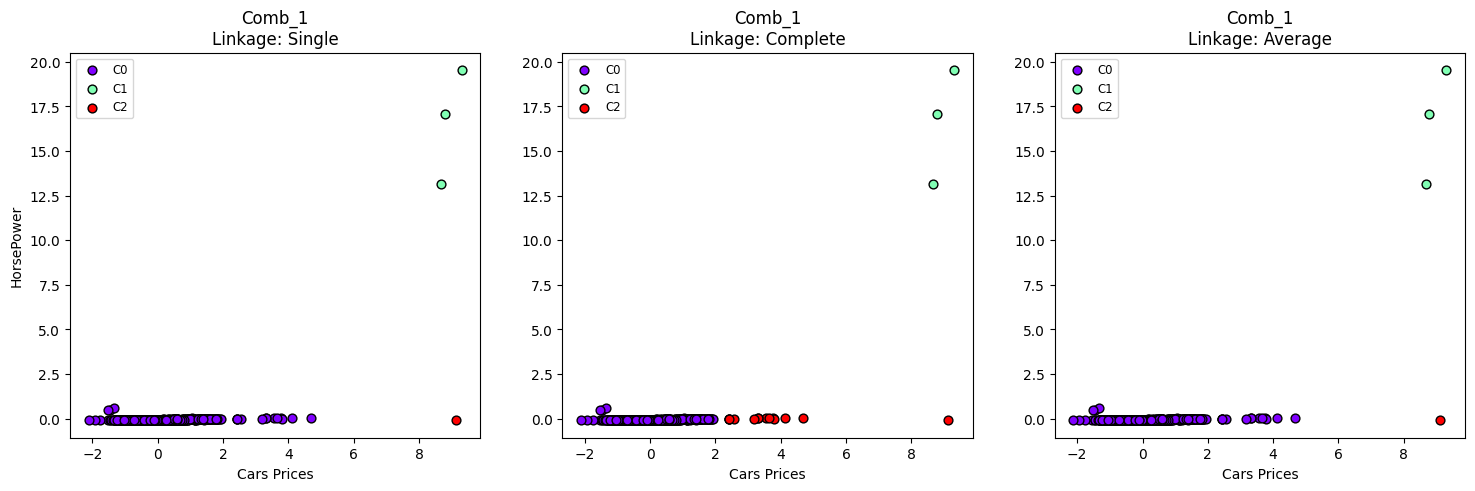

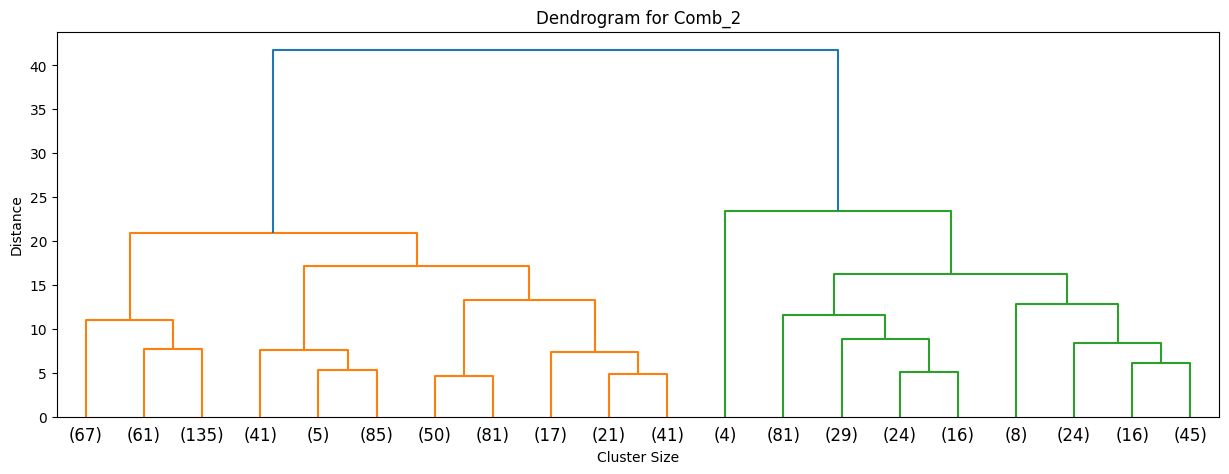

Processing Comb_2 with single linkage...
Starting single clustering on 851 samples...
Hierarchical Silhouette: 0.0216
Processing Comb_2 with complete linkage...
Starting complete clustering on 851 samples...
Hierarchical Silhouette: 0.1807
Processing Comb_2 with average linkage...
Starting average clustering on 851 samples...
Hierarchical Silhouette: 0.2559


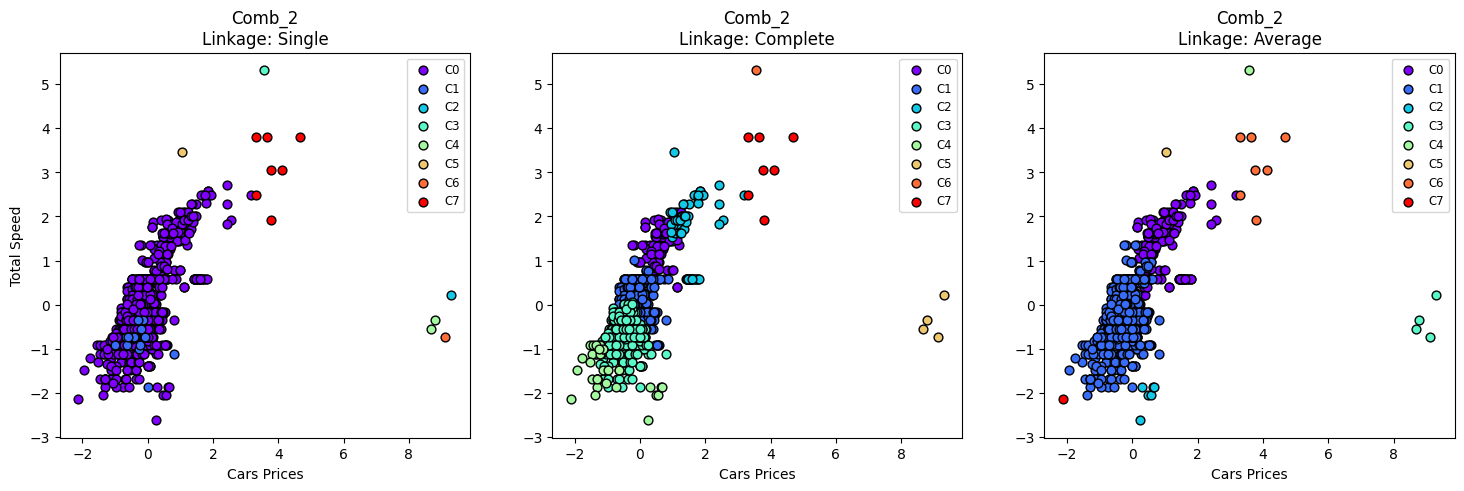

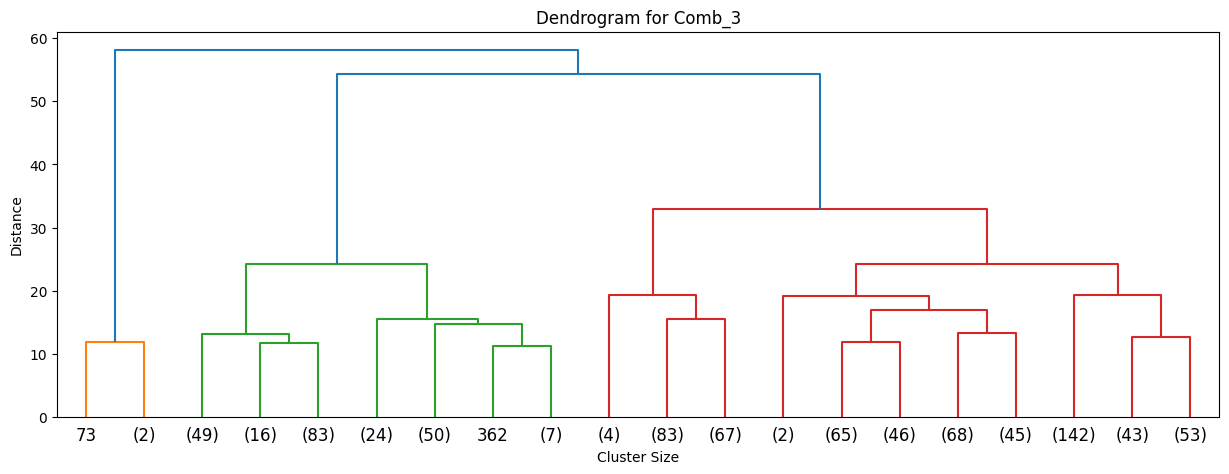

Processing Comb_3 with single linkage...
Starting single clustering on 851 samples...
Hierarchical Silhouette: 0.6406
Processing Comb_3 with complete linkage...
Starting complete clustering on 851 samples...
Hierarchical Silhouette: 0.3097
Processing Comb_3 with average linkage...
Starting average clustering on 851 samples...
Hierarchical Silhouette: 0.5451


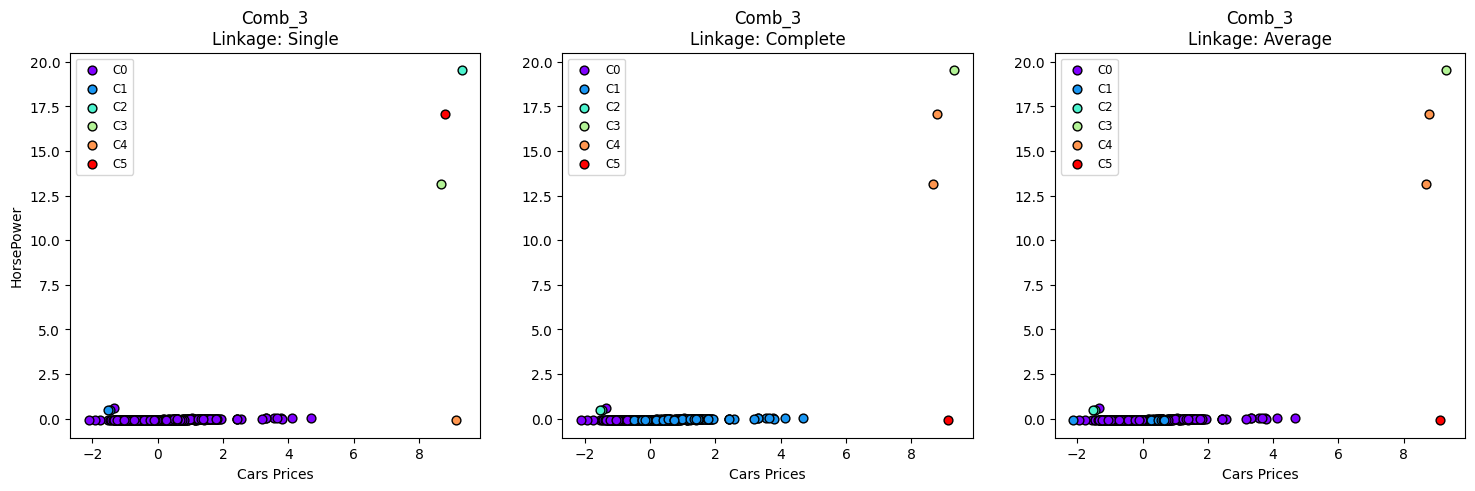

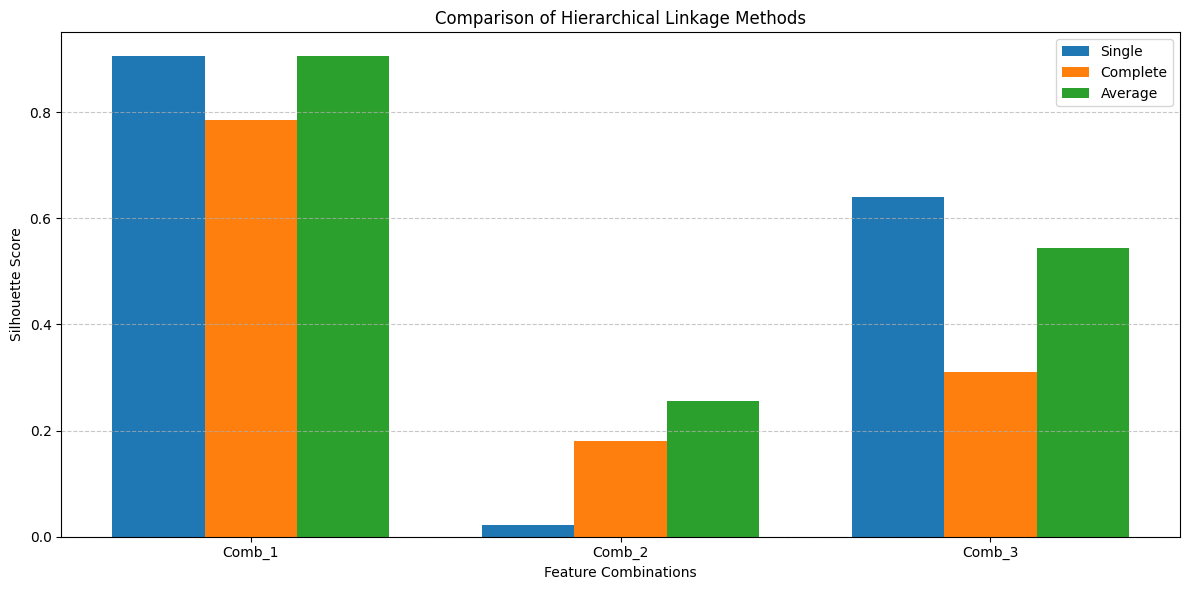

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [19]:
linkages = ['single', 'complete', 'average']
n_clusters = [3, 8, 6]
results = {name: [] for name in combinations.keys()}


for i, (name, features) in enumerate(combinations.items()):
    X_subset = X_train[features].astype(float).values
    current_eps = EPS[i]
    price_idx = features.index('Cars Prices')

    plt.figure(figsize=(15, 5))
    Z = scipy_linkage(X_subset, method='ward') 
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f'Dendrogram for {name}')
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")
    plt.show()

    plt.figure(figsize=(18, 5))
    for j, link_type in enumerate(linkages):
        print(f"Processing {name} with {link_type} linkage...")
        
        hc = Hierarchical(n_clusters=n_clusters[i], linkage=link_type)
        labels = hc.fit(X_subset)
        plt.subplot(1, 3, j+1)
        unique_labels = np.unique(labels)
        colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
        
        hc_sil = get_silhouette_score(X_subset, labels)
        results[name].append(hc_sil)
        print(f"Hierarchical Silhouette: {hc_sil:.4f}")

        for k, col in zip(unique_labels, colors):
            mask = (labels == k)
            plt.scatter(X_subset[mask, price_idx], X_subset[mask, 1], 
                        color=col, s=40, edgecolor='k', label=f'C{int(k)}')
        
        plt.title(f'{name}\nLinkage: {link_type.capitalize()}')
        plt.xlabel('Cars Prices')
        if j == 0: plt.ylabel(features[1])
        plt.legend(fontsize='small')


plt.figure(figsize=(12, 6))
x = np.arange(len(combinations))
width = 0.25 

for i, link in enumerate(linkages):
    scores = [results[name][i] for name in combinations.keys()]
    plt.bar(x + i*width, scores, width, label=link.capitalize())

plt.xlabel('Feature Combinations')
plt.ylabel('Silhouette Score')
plt.title('Comparison of Hierarchical Linkage Methods')
plt.xticks(x + width, combinations.keys())
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, link in enumerate(linkages):
    for j, name in enumerate(combinations.keys()):
        val = results[name][i]
    

    plt.tight_layout()
    plt.show()

--- Comb_1 : ---


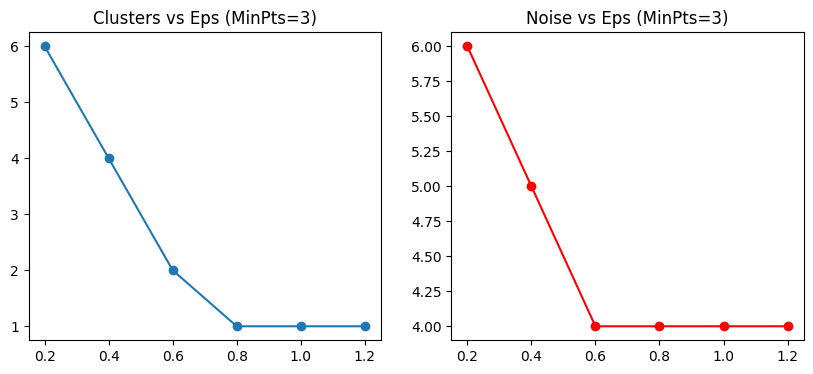

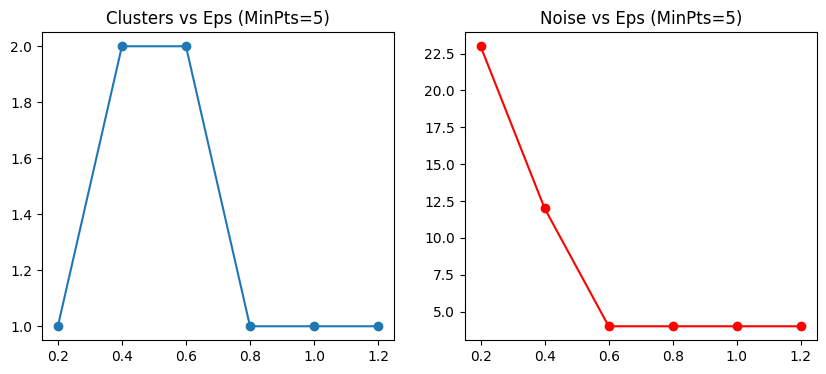

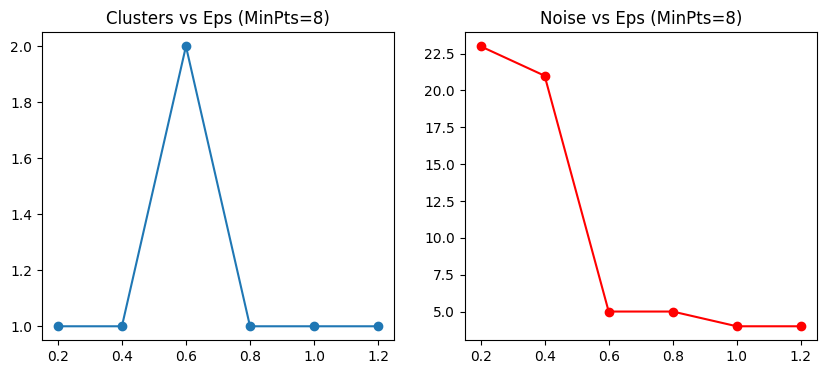

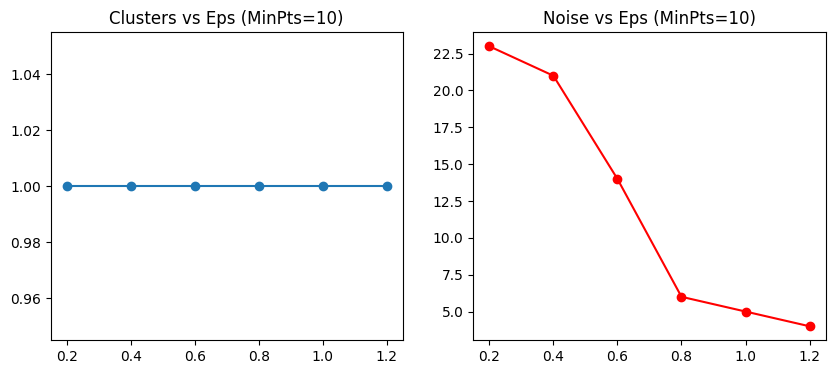

--- Comb_2 : ---


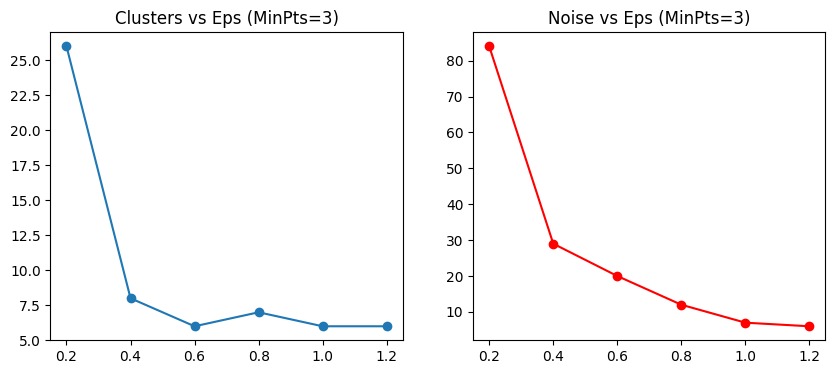

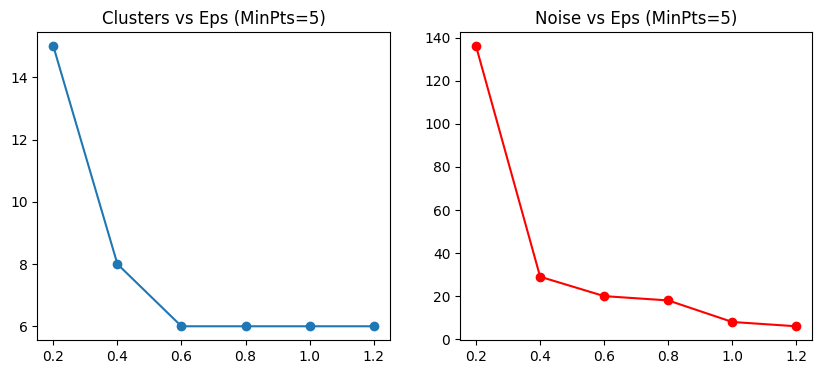

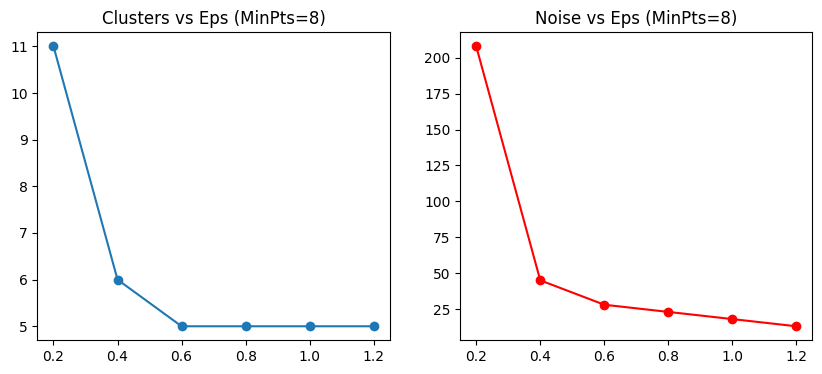

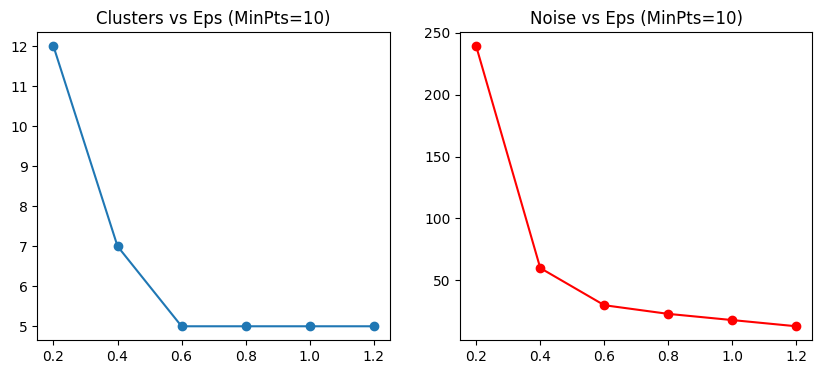

--- Comb_3 : ---


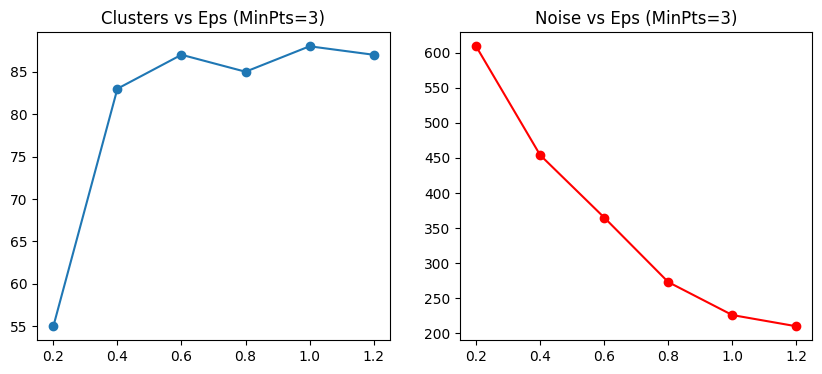

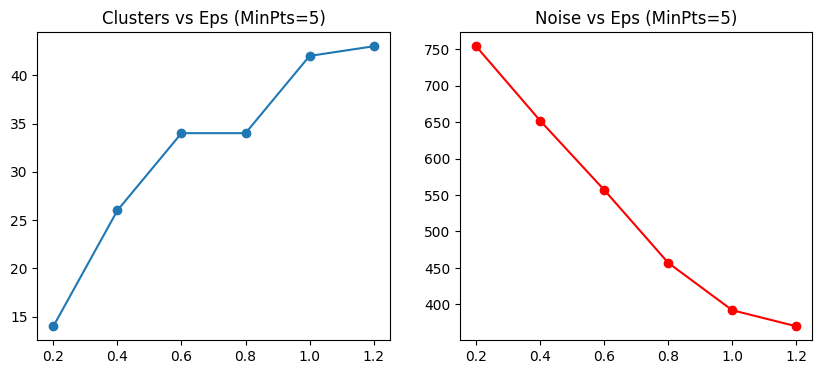

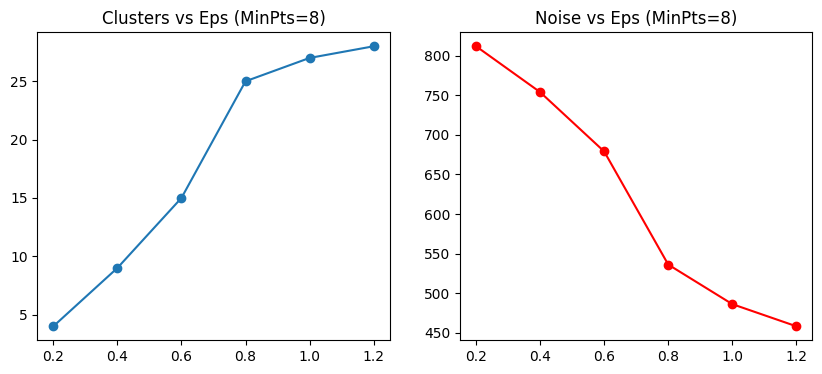

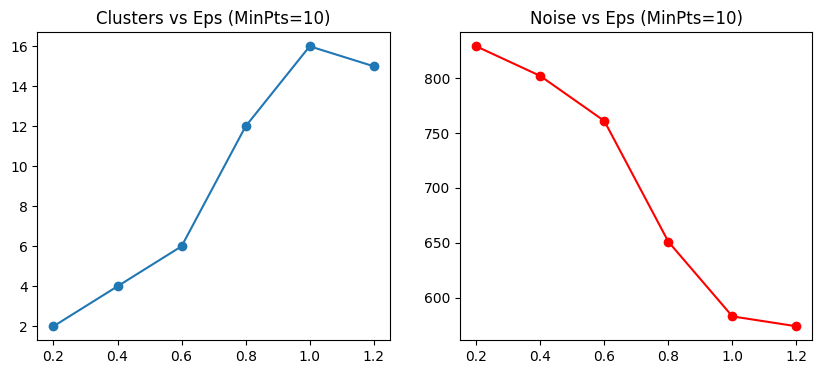

In [20]:
def analyze_dbscan_params(X, eps_values, min_pts_values, name):
    results = []
    print(f"--- {name} : ---")

    for m in min_pts_values:
        n_clusters_list = []
        n_noise_list = []
        for e in eps_values:
            db = DBSCAN(eps=e, min_pts=m).fit(X)
            labels = db.labels_
            
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            n_clusters_list.append(n_clusters)
            n_noise_list.append(n_noise)
            results.append({'name': name, 'eps': e, 'min_pts': m, 'clusters': n_clusters, 'noise': n_noise})
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(eps_values, n_clusters_list, marker='o')
        plt.title(f'Clusters vs Eps (MinPts={m})')
        
        plt.subplot(1, 2, 2)
        plt.plot(eps_values, n_noise_list, marker='o', color='r')
        plt.title(f'Noise vs Eps (MinPts={m})')
        plt.show()
    return results

eps_range = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_pts_range = [3, 5, 8, 10]

for i, (name, features) in enumerate(combinations.items()):
    X_subset = X_train[features].astype(float).values
    analyze_dbscan_params(X_subset, eps_range, min_pts_range, name)


         Cars Prices   HorsePower  Total Speed   Engines
Cluster                                                 
0          10.810999   302.024758   216.676329  V-Engine
1          15.481294  1412.500000   405.000000     Other
2          13.910822   894.333333   339.000000  V-Engine


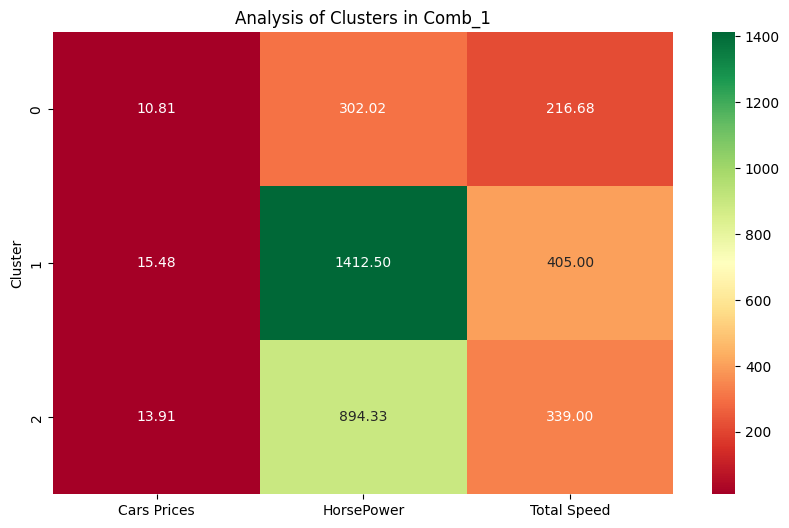

In [21]:
analysis_features = ['Cars Prices', 'HorsePower', 'Total Speed']
comb_features = ['Cars Prices', 'HorsePower']
X_subset = X_train[comb_features]

df_analysis = data.loc[X_subset.index].copy()

df_analysis['Cluster'] = best_labels
df_clusters = df_analysis[df_analysis['Cluster'] != -1]

cluster_table = df_clusters.groupby('Cluster')[analysis_features].mean()
engine_mode = df_analysis[df_analysis['Cluster'] != -1].groupby('Cluster')['Engines'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")

final_summary = pd.concat([cluster_table, engine_mode], axis=1)


print(final_summary)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_table, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title(f'Analysis of Clusters in {best_combination_name}')
plt.show()


In [22]:
def preprocess_user_input(price, hp, speed, preprocessor):
    log_price = np.log1p(price)
    
    user_vals = {
        'Cars Prices': log_price,
        'HorsePower': hp,
        'Total Speed': speed
    }
    
    input_vector = []
    
    for col in preprocessor.num_cols:
        if col in user_vals:
            input_vector.append(user_vals[col])
        else:
            input_vector.append(preprocessor.impute_vals.get(col, 0))
            
    scaled_vector_full = preprocessor.scaler.transform([input_vector])
    
    target_cols = ['Cars Prices', 'HorsePower', 'Total Speed']
    indices = [preprocessor.num_cols.index(col) for col in target_cols]
    
    return scaled_vector_full[0, indices]

In [25]:
def car_recommender(user_input_raw, df_analysis, full_X_scaled, centroids, preprocessor):
    user_vector = preprocess_user_input(
        user_input_raw['price'], 
        user_input_raw['hp'], 
        user_input_raw['speed'], 
        preprocessor
    )

    best_cluster = None
    min_dist = float('inf')
    for cluster_id, centroid_series in centroids.items():
        centroid_vector = centroid_series.values 
        
        dist = np.sqrt(np.sum((user_vector - centroid_vector)**2))
        
        if dist < min_dist:
            min_dist = dist
            best_cluster = cluster_id

    if min_dist > 2.0: 
        print(f"Note: Input is far from all clusters (Dist: {min_dist:.2f}). Searching globally...")
        search_pool = df_analysis.copy()
        pool_indices = full_X_scaled.index
    else:
        search_pool = df_analysis[df_analysis['Cluster'] == best_cluster].copy()
        pool_indices = search_pool.index

    features_to_compare = ['Cars Prices', 'HorsePower', 'Total Speed']
    
    distances = []
    for idx in pool_indices:
        car_vector = full_X_scaled.loc[idx, features_to_compare].values
        d = np.sqrt(np.sum((user_vector - car_vector)**2))
        distances.append(d)
    
    search_pool['distance_to_user'] = distances
    
    top_5 = search_pool.sort_values(by='distance_to_user').head(5)
    
    return best_cluster, top_5.drop(columns=['distance_to_user', 'Cluster'], errors='ignore')


In [ ]:
features_for_clustering = ['Cars Prices', 'HorsePower', 'Total Speed']
centroids = {}
for cluster_id in set(best_labels):
    if cluster_id != -1:
        cluster_points = X_train.loc[best_labels == cluster_id, features_for_clustering]
        centroids[cluster_id] = cluster_points.mean(axis=0)

test_scenarios = [
    {'price': 20000, 'hp': 150, 'speed': 180}, 
    {'price': 150000, 'hp': 600, 'speed': 320},
    {'price': 1000000, 'hp': 1200, 'speed': 400}
]

full_X_scaled = pd.concat([X_train, X_val, X_test])
full_X_scaled = full_X_scaled.sort_index()

for i, scenario in enumerate(test_scenarios):
    print(f"\n{'='*40}")
    print(f"User {i+1} Input: Price=${scenario['price']:,}, HP={scenario['hp']}, Speed={scenario['speed']}")
    
    cluster, cars = car_recommender(scenario, df_analysis, full_X_scaled, centroids, preprocessor)
    
    print(f"Recommended Cluster: {cluster}")
    print("Top 5 Recommended Cars:")
    print(cars)



User 1 Input: Price=$20,000, HP=150, Speed=180
Recommended Cluster: 0
Top 5 Recommended Cars:
     Company Names        Engines  CC/Battery Capacity  HorsePower  Torque  \
436         Nissan  Inline-Engine               1998.0       140.0   186.0   
388         Nissan  Inline-Engine               1598.0       122.0   154.0   
1191         Mazda  Inline-Engine               2000.0       115.0   160.0   
227       MAHINDRA  Inline-Engine               1997.0       150.0   320.0   
214         TOYOTA  Inline-Engine               1496.0       106.0   150.0   

         Fuel Types  Performance(0 - 100 )KM/H  Total Speed  Seats  \
436          Petrol                        9.8        180.0      5   
388          Petrol                       10.7        180.0      5   
1191         Petrol                       12.0        180.0      4   
227   Petrol/Diesel                       10.5        180.0      4   
214          Petrol                       11.2        180.0      5   

      Cars Pric